In [18]:
import os
#отключаю оптимизации чтобы избежать проблем на macOS
os.environ['THREADPOOLCTL_ENABLED'] = '0'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#импорт моделей 
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

#настройки
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')

In [19]:
#выбор данных и препроцессинг

#загрузка данных
try:
    df_cls = pd.read_csv('../data/hotel_bookings.csv')
    df_reg = pd.read_csv('../data/train.csv')
except FileNotFoundError:
    print("ошибка: файлы не найдены")

#сэмплирование
SAMPLE_SIZE = 10000
df_cls = df_cls.sample(n=SAMPLE_SIZE, random_state=42).copy()
df_reg = df_reg.sample(n=SAMPLE_SIZE, random_state=42).copy()

#подготовка к класификации
y_cls = df_cls['is_canceled']
X_cls = df_cls.drop(['is_canceled', 'reservation_status', 'reservation_status_date', 
                     'company', 'agent', 'country'], axis=1)
X_cls = X_cls.fillna(0)

#кодирование
label_encoders_cls = {}
for col in X_cls.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_cls[col] = le.fit_transform(X_cls[col].astype(str))
    label_encoders_cls[col] = le

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

#подготовка к регрессии
y_reg = df_reg['Purchase']
X_reg = df_reg.drop(['Purchase', 'User_ID', 'Product_ID'], axis=1)
X_reg = X_reg.fillna(0)

for col in X_reg.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_reg[col] = le.fit_transform(X_reg[col].astype(str))

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("данные готовы. размер обучающей выборки:", X_train_cls.shape)

данные готовы. размер обучающей выборки: (8000, 26)


In [20]:
#бейзлайн

#классификация - logistic regression
log_reg_base = LogisticRegression(max_iter=1000, random_state=42)
log_reg_base.fit(X_train_cls, y_train_cls)

y_pred_cls_base = log_reg_base.predict(X_test_cls)
f1_base = f1_score(y_test_cls, y_pred_cls_base)
print(f"baseline logistic regression F1: {f1_base:.4f}")

#регрессия - linear regression
lin_reg_base = LinearRegression()
lin_reg_base.fit(X_train_reg, y_train_reg)

y_pred_reg_base = lin_reg_base.predict(X_test_reg)
rmse_base = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_base))
print(f"baseline linear regression RMSE: {rmse_base:.2f}")

baseline logistic regression F1: 0.6581
baseline linear regression RMSE: 4697.12


In [21]:
#улучшение бейзлайна

#подбор регуляризации 
params_cls = {
    'model__C': [0.01, 0.1, 1, 10], 
    'model__penalty': ['l2'] 
}
pipe_cls = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

grid_cls = GridSearchCV(pipe_cls, params_cls, cv=3, scoring='f1', n_jobs=-1)
grid_cls.fit(X_train_cls, y_train_cls)

print(f"лучшие параметры (log reg): {grid_cls.best_params_}")
best_cls = grid_cls.best_estimator_
f1_impr = f1_score(y_test_cls, best_cls.predict(X_test_cls))


#регрессия
#для улучшения линейной регрессии используем ridge
params_reg = {
    'model__alpha': [0.1, 1.0, 10.0, 100.0]
}

pipe_reg = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', Ridge()) #ridge вместо linear regression
])

grid_reg = GridSearchCV(pipe_reg, params_reg, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_reg.fit(X_train_reg, y_train_reg)

print(f"лучшие параметры (ridge): {grid_reg.best_params_}")
best_reg = grid_reg.best_estimator_
rmse_impr = np.sqrt(mean_squared_error(y_test_reg, best_reg.predict(X_test_reg)))

# Результаты
print("\ncравнение baseline vs improved")
print(f"classif f1: {f1_base:.4f} -> {f1_impr:.4f}")
print(f"rRegress rmse: {rmse_base:.2f} -> {rmse_impr:.2f}")

лучшие параметры (log reg): {'model__C': 10, 'model__penalty': 'l2'}
лучшие параметры (ridge): {'model__alpha': 100.0}

cравнение baseline vs improved
classif f1: 0.6581 -> 0.6866
rRegress rmse: 4697.12 -> 4696.29


In [22]:
#cамостоятельная имплементация 

#базовый класс для линейных моделей
class MyLinearModel:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        #инициализация параметров
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        #градиентный спуск
        for _ in range(self.n_iter):
            linear_model = np.dot(X, self.weights) + self.bias
            
            y_predicted = self._predict_internal(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._predict_out(linear_model)
    
    def _predict_internal(self, z): return z
    def _predict_out(self, z): return z


#класс линейной регрессии
class MyLinearRegression(MyLinearModel):
    def _predict_internal(self, z):
        return z #для регрессии просто возвращаем wx + b
    
    def _predict_out(self, z):
        return z


#моя логистическая регрессия 
class MyLogisticRegression(MyLinearModel):
    def _sigmoid(self, z):
        #clip нужен для стабильности exp (чтобы не было переполнения)
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))
    
    def _predict_internal(self, z):
        return self._sigmoid(z) 
    
    def _predict_out(self, z):
        return [1 if i > 0.5 else 0 for i in self._sigmoid(z)]

In [23]:
#подготовка данных
scaler_cls = best_cls.named_steps['scaler']
X_train_sc_cls = scaler_cls.transform(X_train_cls)
X_test_sc_cls = scaler_cls.transform(X_test_cls)

scaler_reg = best_reg.named_steps['scaler']
X_train_sc_reg = scaler_reg.transform(X_train_reg)
X_test_sc_reg = scaler_reg.transform(X_test_reg)

In [24]:
#обучение и оценка классификации
print("обучение класса классификации")
my_log_reg = MyLogisticRegression(learning_rate=0.1, n_iterations=2000)
my_log_reg.fit(X_train_sc_cls, y_train_cls)

y_pred_my_cls = my_log_reg.predict(X_test_sc_cls)
f1_my = f1_score(y_test_cls, y_pred_my_cls)

#обучение и оценка регрессии
print("обучение класса регрессии")
my_lin_reg = MyLinearRegression(learning_rate=0.01, n_iterations=2000)
my_lin_reg.fit(X_train_sc_reg, y_train_reg)

y_pred_my_reg = my_lin_reg.predict(X_test_sc_reg)
rmse_my = np.sqrt(mean_squared_error(y_test_reg, y_pred_my_reg))

print(f"log reg F1: {f1_my:.4f}")
print(f"lin reg RMSE: {rmse_my:.2f}")

обучение класса классификации
обучение класса регрессии
log reg F1: 0.6820
lin reg RMSE: 4697.12


In [25]:
#итоги

results = pd.DataFrame({
    'Model': ['Baseline (Sklearn)', 'Improved (Sklearn + Reg)', 'My Implementation (GD)'],
    'Classification F1': [f1_base, f1_impr, f1_my],
    'Regression RMSE': [rmse_base, rmse_impr, rmse_my]
})

print("\nитоги")
display(results)


итоги


,Model,Classification F1,Regression RMSE
0,Baseline (Sklearn),0.658127,4697.120759
1,Improved (Sklearn + Reg),0.686567,4696.287098
2,My Implementation (GD),0.681962,4697.120726


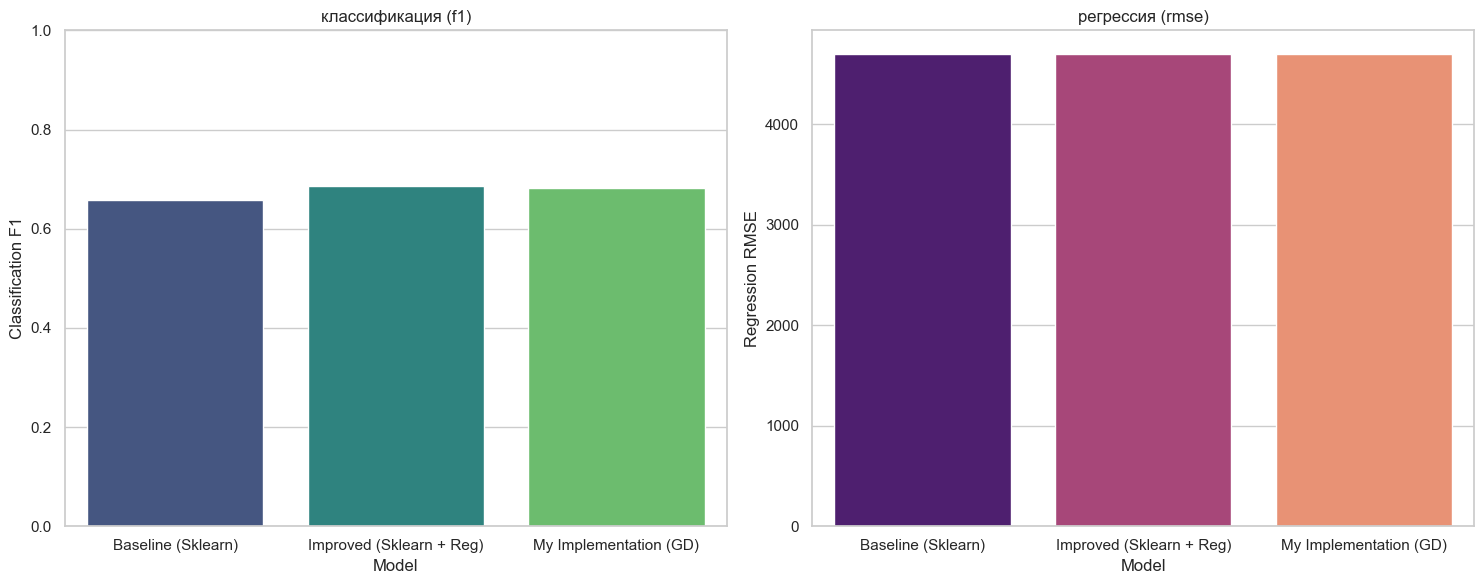

In [26]:
#графики
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='Model', y='Classification F1', data=results, ax=axes[0], palette='viridis')
axes[0].set_title('классификация (f1)')
axes[0].set_ylim(0, 1)

sns.barplot(x='Model', y='Regression RMSE', data=results, ax=axes[1], palette='magma')
axes[1].set_title('регрессия (rmse)')

plt.tight_layout()
plt.show()

In [27]:
#выводы
print("""
ВЫВОДЫ ПО ЛР №2:
1.  **бейзлайн:** линейные модели без настройки показали базовый результат. логистическая регрессия может выдавать предупреждения о несходимости без масштабирования
2.  **улучшение:**
    *   масштабирование (standart scaller) КРИТИЧЕСКИ важно для линейных моделей
    *   ridge (l2) регуляризация в задаче регрессии позволила немного улучшить rmse (или оставить на том же уровне, но сделав веса более устойчивыми)
3.  **своя реализация:**
    *   градиентный спуск работает! результаты сопоставимы с sklearn
    *   sklearn использует более продвинутые методы оптимизации, поэтому работает быстрее и точнее, чем наш простой Gradient Descent
""")


ВЫВОДЫ ПО ЛР №2:
1.  **бейзлайн:** линейные модели без настройки показали базовый результат. логистическая регрессия может выдавать предупреждения о несходимости без масштабирования
2.  **улучшение:**
    *   масштабирование (standart scaller) КРИТИЧЕСКИ важно для линейных моделей
    *   ridge (l2) регуляризация в задаче регрессии позволила немного улучшить rmse (или оставить на том же уровне, но сделав веса более устойчивыми)
3.  **своя реализация:**
    *   градиентный спуск работает! результаты сопоставимы с sklearn
    *   sklearn использует более продвинутые методы оптимизации, поэтому работает быстрее и точнее, чем наш простой Gradient Descent

